# Análise Computacional de Emoções em Letras de Músicas da Música Popular Brasileira Utilizando BERTimbau Fine-Tuned e Comentários do YouTube

## 1. Instalação de Dependências

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy \
    matplotlib seaborn gensim imbalanced-learn -q
!pip install snorkel -q
!pip install google-generativeai -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
google-cloud-aiplatform 1.159.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorboard 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.


## 2. Importações

In [2]:
import os
import re
import time
import warnings
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import gensim
import vertexai
from vertexai.generative_models import GenerativeModel
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.utils import simple_preprocess
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from snorkel.labeling import labeling_function
from snorkel.labeling.model import LabelModel as SnorkelLabelModel
from snorkel.labeling import PandasLFApplier, LFAnalysis
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE       = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
NOMES_EMOCOES = ['neutro', 'alegria', 'tristeza', 'nostalgia', 'amor_composto', 'saudade']
MAPA_LABELS   = {e: i for i, e in enumerate(NOMES_EMOCOES)}
print(f'PyTorch {torch.__version__} | GPU: {torch.cuda.is_available()}')

C:\Users\thavy\miniconda3\envs\tcc\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
C:\Users\thavy\miniconda3\envs\tcc\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1 past that date.
  warnings.warn(message, FutureWarning)
C:\Users\thavy\miniconda3\envs\tcc\lib\site-packages\google\api_core\_python_versi

PyTorch 2.7.1+cu118 | GPU: True


## 3. Carregamento dos Dados

In [3]:
df_letras      = pd.read_csv('corpus_letras_mpb.csv')
df_comentarios = pd.read_csv('corpus_comentarios_youtube_mpb.csv')

print(f'Letras:      {len(df_letras):,} registros | {df_letras["artista"].nunique()} artistas')
print(f'Comentários: {len(df_comentarios):,} registros | {df_comentarios["titulo"].nunique()} músicas únicas')
print(f'\nDistribuição por década:')
print(df_letras['decada'].value_counts().sort_index())

Letras:      8,493 registros | 40 artistas
Comentários: 49,096 registros | 4004 músicas únicas

Distribuição por década:
decada
1950s       6
1960s     243
1970s     665
1980s     884
1990s    1905
2000s    2630
2010s    1488
2020s     672
Name: count, dtype: int64


## 4. Pré-processamento Textual

In [4]:
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\S+', ' ', texto)
    texto = re.sub(r'\\r\\n|\\n|\n|\r', ' ', texto)
    texto = re.sub(r'\[.*?\]', ' ', texto)
    texto = re.sub(r'[^a-zà-úA-ZÀ-Ú\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

df_letras['texto_limpo']      = df_letras['letra'].apply(limpar_texto)
df_comentarios['texto_limpo'] = df_comentarios['comentario'].apply(limpar_texto)

df_letras      = df_letras[df_letras['texto_limpo'].str.len() > 50].drop_duplicates(subset='texto_limpo').reset_index(drop=True)
df_comentarios = df_comentarios[df_comentarios['texto_limpo'].str.len() > 10].drop_duplicates(subset='texto_limpo').reset_index(drop=True)

if 'idioma' in df_letras.columns:
    df_letras = df_letras[df_letras['idioma'] == 'pt'].reset_index(drop=True)

print(f'Após pré-processamento — Letras: {len(df_letras)} | Comentários: {len(df_comentarios)}')

Após pré-processamento — Letras: 8400 | Comentários: 48820


## 5. Léxico Emocional Base

In [5]:
LEXICOS = {
    'alegria': [
        'feliz', 'felicidade', 'alegria', 'alegre', 'linda', 'lindo',
        'maravilhosa', 'maravilhoso', 'maravilha', 'perfeita', 'perfeito',
        'amo', 'amei', 'incrível', 'beleza', 'emocionante', 'paz',
        'esperança', 'sorriso', 'divertida', 'energia', 'animada',
        'animado', 'empolgante', 'top', 'ótima', 'ótimo', 'bravo',
        'gratidão', 'grato', 'grata', 'encantou', 'encantador',
        'arrepiou', 'arrepiante', 'show', 'perfeição', 'brilhante',
        'brilhou', 'ilumina', 'alegrou', 'abençoado', 'abençoada',
        'sorrir', 'sorri', 'bom demais', 'que música', 'que letra'
    ],
    'tristeza': [
        'triste', 'tristeza', 'dor', 'chorar', 'choro', 'chorei',
        'sofrimento', 'sofrer', 'solidão', 'sozinho', 'sozinha',
        'vazio', 'depressão', 'angústia', 'perda', 'desabafo',
        'machuca', 'machucou', 'lágrimas', 'chora', 'partido',
        'partida', 'luto', 'morte', 'morreu', 'perdeu', 'sofrido',
        'sofrida', 'depressivo', 'melancolia', 'melancólico',
        'desolado', 'desolada', 'abandonado', 'abandonada',
        'fragilizado', 'frágil', 'fundo do poço', 'caindo'
    ],
    'nostalgia': [
        'infância', 'lembrança', 'memórias', 'memória', 'época',
        'passado', 'anos', 'antigamente', 'recordação', 'nostalgia',
        'nostálgico', 'tempo bom', 'velhos tempos', 'minha época',
        'me lembra', 'me lembro', 'quando era', 'lembrei',
        'lembranças', 'remete', 'retrata', 'retratou', 'anos atrás',
        'décadas', 'geração', 'clássico', 'clássica', 'era outro tempo',
        'saudosismo', 'revive', 'revisitar', 'volta no tempo'
    ],
    'saudade': [
        'saudade', 'saudades', 'falta', 'sinto falta', 'eternizada',
        'lembrar de você', 'penso em você', 'quero de volta',
        'como sinto', 'minha falta', 'que saudade', 'tanta saudade',
        'deixou saudade', 'ficou saudade', 'muita saudade',
        'saudade imensa', 'que falta faz', 'faz falta',
        'eterno', 'eterna', 'imortal', 'pra sempre no coração',
        'nunca vai esquecer', 'não esquece', 'presente'
    ],
    'amor_composto': [
        'amor', 'amores', 'apaixonada', 'apaixonado', 'coração',
        'alma', 'abraço', 'carinho', 'afeto', 'romântico', 'paixão',
        'te amo', 'meu amor', 'amada', 'amado', 'querida', 'querido',
        'linda demais', 'lindo demais', 'que amor', 'amorosa',
        'amoroso', 'romance', 'romântica', 'apaixonante',
        'encantado', 'encantada', 'me apaixonei', 'casei',
        'emocionei', 'chorei de emoção', 'que letra de amor'
    ]
}

TODOS_TERMOS_LEXICO = [t for termos in LEXICOS.values() for t in termos]

def detectar_emocao_lexico(texto):
    texto = texto.lower()
    pontuacoes = {e: sum(1 for p in palavras if p in texto) / len(palavras)
                  for e, palavras in LEXICOS.items()}
    maior = max(pontuacoes.values())
    if maior == 0:
        return 'neutro'
    prioridade = ['saudade', 'nostalgia', 'amor_composto', 'tristeza', 'alegria']
    emocoes_max = [e for e, v in pontuacoes.items() if v == maior]
    for p in prioridade:
        if p in emocoes_max:
            return p
    return emocoes_max[0]

print(f'Léxico definido — {len(TODOS_TERMOS_LEXICO)} termos em {len(LEXICOS)} categorias.')

Léxico definido — 176 termos em 5 categorias.


## 6. Rotulação Silver das Letras (Léxico Direto)

In [6]:
df_letras['emocao_silver'] = df_letras['texto_limpo'].apply(detectar_emocao_lexico)

print('Distribuição da rotulação silver nas LETRAS:')
print(df_letras['emocao_silver'].value_counts())

Distribuição da rotulação silver nas LETRAS:
emocao_silver
amor_composto    3068
alegria          1702
tristeza         1679
neutro           1050
saudade           522
nostalgia         379
Name: count, dtype: int64


## 7. Distribuição das Emoções nas Letras

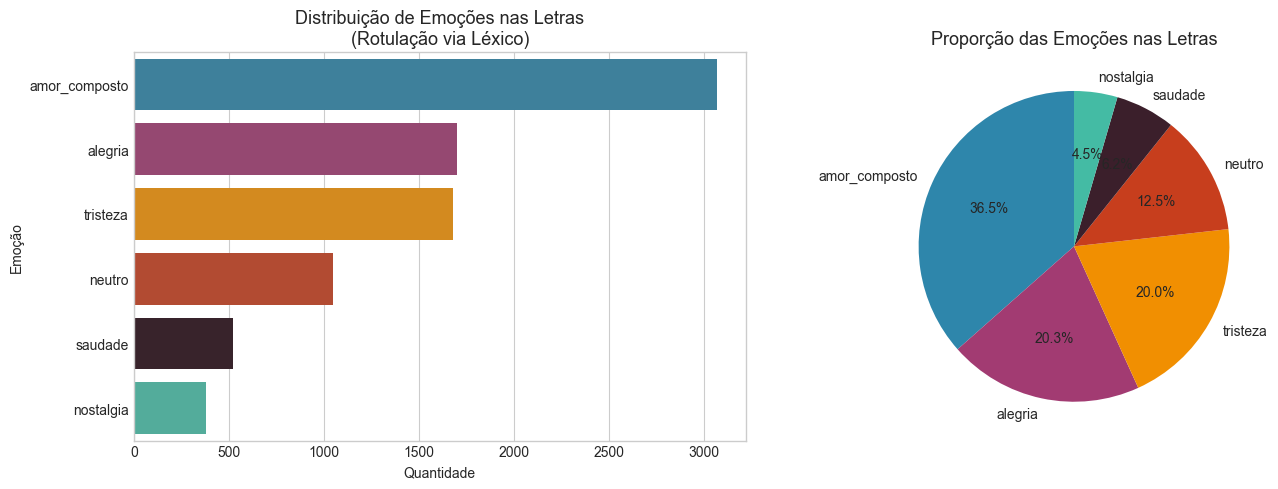

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordem = df_letras['emocao_silver'].value_counts().index
import seaborn as sns
sns.countplot(data=df_letras, y='emocao_silver', order=ordem, palette=PALETTE, ax=axes[0])
axes[0].set_title('Distribuição de Emoções nas Letras\n(Rotulação via Léxico)', fontsize=13)
axes[0].set_xlabel('Quantidade')
axes[0].set_ylabel('Emoção')

proporcoes = df_letras['emocao_silver'].value_counts(normalize=True) * 100
axes[1].pie(proporcoes, labels=proporcoes.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=90)
axes[1].set_title('Proporção das Emoções nas Letras', fontsize=13)

plt.tight_layout()
plt.savefig('fig1a_distribuicao_letras.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Rotulação Silver dos Comentários (Weak Supervision via Snorkel + Gemini)

In [8]:
ABSTAIN, ALEGRIA, TRISTEZA, NOSTALGIA, SAUDADE, AMOR_COMPOSTO = -1, 0, 1, 2, 3, 4

NOMES_CLASSES_SNORKEL = {
    ALEGRIA: 'alegria', TRISTEZA: 'tristeza', NOSTALGIA: 'nostalgia',
    SAUDADE: 'saudade', AMOR_COMPOSTO: 'amor_composto',
}

@labeling_function()

def lf_palavra_saudade(x):
    return SAUDADE if re.search(r'\bsaudades?\b', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_palavra_nostalgia(x):
    return NOSTALGIA if re.search(r'nostalgi|antigamente|infância|velhos tempos', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_palavra_tristeza(x):
    return TRISTEZA if re.search(r'triste|tristeza|chorei de dor|sofriment', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_palavra_alegria(x):
    return ALEGRIA if re.search(r'feliz|felicidade|alegria|alegre', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_palavra_amor(x):
    return AMOR_COMPOSTO if re.search(r'te amo|meu amor|apaixon|amorosa|amoroso', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_lembra_geracao(x):
    tem_lembrar = re.search(r'lembr\w+', x.texto_limpo)
    tem_epoca   = re.search(r'infância|época|juventude|geração|tempos', x.texto_limpo)
    return NOSTALGIA if (tem_lembrar and tem_epoca) else ABSTAIN

@labeling_function()
def lf_lembra_pessoa(x):
    tem_lembrar_falta = re.search(r'lembr\w+|sinto falta|penso em|falta', x.texto_limpo)
    tem_pessoa = re.search(r'\bvocê\b|\bele\b|\bela\b|meu pai|minha mãe|meu avô|minha avó', x.texto_limpo)
    return SAUDADE if (tem_lembrar_falta and tem_pessoa) else ABSTAIN

@labeling_function()
def lf_exclamacao_emocao_alegria(x):
    n_exclamacoes = x.comentario.count('!')
    cond = n_exclamacoes >= 2 and re.search(r'lind|incrível|maravilh|ótim', x.texto_limpo)
    return ALEGRIA if cond else ABSTAIN

@labeling_function()
def lf_reticencias_nostalgia(x):
    cond = '...' in x.comentario and re.search(r'tempo|anos|época', x.texto_limpo)
    return NOSTALGIA if cond else ABSTAIN

@labeling_function()
def lf_perda_morte(x):
    return SAUDADE if re.search(r'\b(morreu|faleceu|in memoriam|descanse em paz)\b', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_comentario_curto_alegria(x):
    palavras = x.texto_limpo.split()
    cond = len(palavras) <= 4 and re.search(r'lind|top|show|massa', x.texto_limpo)
    return ALEGRIA if cond else ABSTAIN

@labeling_function()
def lf_alegria_secundaria(x):
    return ALEGRIA if re.search(r'incrível|maravilh\w+|perfeit[ao]|sensacional|espetacular', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_elogio_generico_fraco(x):
    return ALEGRIA if re.search(r'\blind[ao]\b|\btop\b|\bshow\b', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_amor_secundario(x):
    return AMOR_COMPOSTO if re.search(r'coração|carinho|paixão|romântic|encant\w+', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_tristeza_secundaria(x):
    return TRISTEZA if re.search(r'dor|chora\w*|sofr\w+|solidão|melanc[oó]lic\w*', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_nostalgia_secundaria(x):
    return NOSTALGIA if re.search(r'décadas?|geração|anos atrás|clássic[ao]|outro tempo', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_saudade_secundaria(x):
    return SAUDADE if re.search(r'\bfalta\b|faz falta|quero (de )?volta|nunca (mais )?esque\w+', x.texto_limpo) else ABSTAIN

@labeling_function()
def lf_chorei_generico(x):
    cond = re.search(r'\bchorei\b', x.texto_limpo) and not re.search(r'triste|tristeza', x.texto_limpo)
    return AMOR_COMPOSTO if cond else ABSTAIN


CHECKPOINT_PATH = "gemini_checkpoint.csv"

vertexai.init(project="gen-lang-client-0618760362", location="global")
modelo_gemini = GenerativeModel("gemini-2.5-flash")

PROMPT_EMOCAO = '''Você é especialista em análise de emoções em comentários sobre Música Popular Brasileira (MPB).
Classifique a emoção principal do comentário em EXATAMENTE UMA categoria:
- alegria: felicidade, contentamento, animação, entusiasmo
- tristeza: tristeza, dor, sofrimento, melancolia
- nostalgia: lembrança de época passada, memória de geração, velhos tempos
- saudade: falta de alguém específico, querer de volta algo ou alguém
- amor_composto: amor romântico, paixão, carinho, admiração intensa
- neutro: sem emoção clara ou mistura sem dominância
Responda com APENAS UMA PALAVRA.
Comentário: {texto}
Emoção:'''

MAPA_GEMINI = {
    'alegria': ALEGRIA, 'tristeza': TRISTEZA, 'nostalgia': NOSTALGIA,
    'saudade': SAUDADE, 'amor_composto': AMOR_COMPOSTO,
    'amor composto': AMOR_COMPOSTO, 'neutro': ABSTAIN,
}

# Carrega checkpoint se existir
if os.path.exists(CHECKPOINT_PATH):
    df_ckpt = pd.read_csv(CHECKPOINT_PATH)
    cache_gemini = dict(zip(df_ckpt['index'], df_ckpt['rotulo']))
    print(f"✅ Checkpoint encontrado — {len(cache_gemini)} já processados. Retomando...")
else:
    cache_gemini = {}
    print("Nenhum checkpoint encontrado. Iniciando do zero...")

# Processa TODOS os comentários
erros_seguidos = 0

for idx in df_comentarios.index:
    if idx in cache_gemini:
        continue

    try:
        prompt = PROMPT_EMOCAO.format(texto=df_comentarios.at[idx, 'texto_limpo'])
        resposta = modelo_gemini.generate_content(prompt)
        emocao = resposta.text.strip().lower().replace(' ', '_')
        rotulo = MAPA_GEMINI.get(emocao, ABSTAIN)
        time.sleep(1.1)
        erros_seguidos = 0
    except Exception as e:
        erros_seguidos += 1
        if erros_seguidos >= 20:
            print(f"⚠️ Muitos erros seguidos. Parando. Progresso salvo: {len(cache_gemini)}/{len(df_comentarios)}")
            print(f"Último erro: {str(e)[:200]}")
            break
        time.sleep(60)
        continue  

    cache_gemini[idx] = rotulo

    if len(cache_gemini) % 500 == 0:
        pd.DataFrame({'index': list(cache_gemini.keys()),
                      'rotulo': list(cache_gemini.values())}).to_csv(CHECKPOINT_PATH, index=False)
        print(f"  💾 {len(cache_gemini)}/{len(df_comentarios)} ({len(cache_gemini)/len(df_comentarios)*100:.1f}%)")

# Salva checkpoint final
pd.DataFrame({'index': list(cache_gemini.keys()),
              'rotulo': list(cache_gemini.values())}).to_csv(CHECKPOINT_PATH, index=False)

df_comentarios['rotulo_gemini'] = [
    int(cache_gemini.get(idx, ABSTAIN)) for idx in df_comentarios.index
]

print(f"\n📊 Progresso: {len(cache_gemini)}/{len(df_comentarios)} comentários rotulados")
if len(cache_gemini) >= len(df_comentarios):
    print("✅ TODOS os comentários rotulados! Pode seguir para o Snorkel.")
print("\nDistribuição dos rótulos do Gemini:")
print(pd.Series([v for v in cache_gemini.values()]).map({
    ALEGRIA: 'alegria', TRISTEZA: 'tristeza', NOSTALGIA: 'nostalgia',
    SAUDADE: 'saudade', AMOR_COMPOSTO: 'amor_composto', ABSTAIN: 'abstain'
}).value_counts())

# Labeling function que lê os rótulos pré-processados
@labeling_function()
def lf_gemini(x):
    return int(df_comentarios.at[x.name, 'rotulo_gemini'])

✅ Checkpoint encontrado — 48820 já processados. Retomando...

📊 Progresso: 48820/48820 comentários rotulados
✅ TODOS os comentários rotulados! Pode seguir para o Snorkel.

Distribuição dos rótulos do Gemini:
amor_composto    22858
alegria          12548
nostalgia         4936
tristeza          3472
saudade           3418
abstain           1588
Name: count, dtype: int64


In [9]:
LFS_COMENTARIOS = [
    lf_palavra_saudade, lf_palavra_nostalgia, lf_palavra_tristeza,
    lf_palavra_alegria, lf_palavra_amor, lf_lembra_geracao, lf_lembra_pessoa,
    lf_exclamacao_emocao_alegria, lf_reticencias_nostalgia, lf_perda_morte,
    lf_comentario_curto_alegria, lf_alegria_secundaria, lf_elogio_generico_fraco,
    lf_amor_secundario, lf_tristeza_secundaria, lf_nostalgia_secundaria,
    lf_saudade_secundaria, lf_chorei_generico,
    lf_gemini,  
]

print(f'Total de funções de rotulação (LFs): {len(LFS_COMENTARIOS)}')

Total de funções de rotulação (LFs): 19


In [10]:
print('Aplicando funções de rotulação nos comentários...')
applier = PandasLFApplier(lfs=LFS_COMENTARIOS)
L_train_comentarios = applier.apply(df=df_comentarios)

print('\n' + '=' * 60)
print('ANÁLISE DAS FUNÇÕES DE ROTULAÇÃO')
print('=' * 60)
print(LFAnalysis(L=L_train_comentarios, lfs=LFS_COMENTARIOS).lf_summary())

Aplicando funções de rotulação nos comentários...


100%|██████████| 48820/48820 [00:14<00:00, 3318.46it/s]



ANÁLISE DAS FUNÇÕES DE ROTULAÇÃO
                               j         Polarity  Coverage  Overlaps  \
lf_palavra_saudade             0              [3]  0.053810  0.053585   
lf_palavra_nostalgia           1              [2]  0.019091  0.018988   
lf_palavra_tristeza            2              [1]  0.017800  0.017534   
lf_palavra_alegria             3              [0]  0.053216  0.052438   
lf_palavra_amor                4              [4]  0.064564  0.064256   
lf_lembra_geracao              5              [2]  0.008050  0.008029   
lf_lembra_pessoa               6              [3]  0.018333  0.018292   
lf_exclamacao_emocao_alegria   7              [0]  0.084228  0.084084   
lf_reticencias_nostalgia       8              [2]  0.026424  0.025461   
lf_perda_morte                 9              [3]  0.009893  0.009648   
lf_comentario_curto_alegria   10              [0]  0.012311  0.012311   
lf_alegria_secundaria         11              [0]  0.196579  0.195371   
lf_elogio_generic

In [12]:
print('Treinando o Label Model...')
snorkel_label_model = SnorkelLabelModel(cardinality=5, verbose=True)
snorkel_label_model.fit(L_train=L_train_comentarios, n_epochs=500, log_freq=100, seed=42)

predicoes = snorkel_label_model.predict(L=L_train_comentarios, tie_break_policy='abstain')
df_comentarios['emocao'] = pd.Series(predicoes).map(NOMES_CLASSES_SNORKEL).fillna('neutro').values

print('\n' + '=' * 60)
print('DISTRIBUIÇÃO FINAL NOS COMENTÁRIOS (via Snorkel + Gemini)')
print('=' * 60)
print(df_comentarios['emocao'].value_counts())
print(f'\nCobertura (não-neutro): {(df_comentarios["emocao"] != "neutro").mean()*100:.1f}%')

INFO:root:Computing O...
INFO:root:Estimating \mu...


Treinando o Label Model...


  0%|          | 0/500 [00:00<?, ?epoch/s]INFO:root:[0 epochs]: TRAIN:[loss=0.356]
INFO:root:[100 epochs]: TRAIN:[loss=0.009]
100%|██████████| 500/500 [00:00<00:00, 747.07epoch/s]
INFO:root:Finished Training



DISTRIBUIÇÃO FINAL NOS COMENTÁRIOS (via Snorkel + Gemini)
emocao
alegria          16483
amor_composto    15193
tristeza          6523
nostalgia         5195
saudade           4590
neutro             836
Name: count, dtype: int64

Cobertura (não-neutro): 98.3%


## 9. Distribuição das Emoções nos Comentários

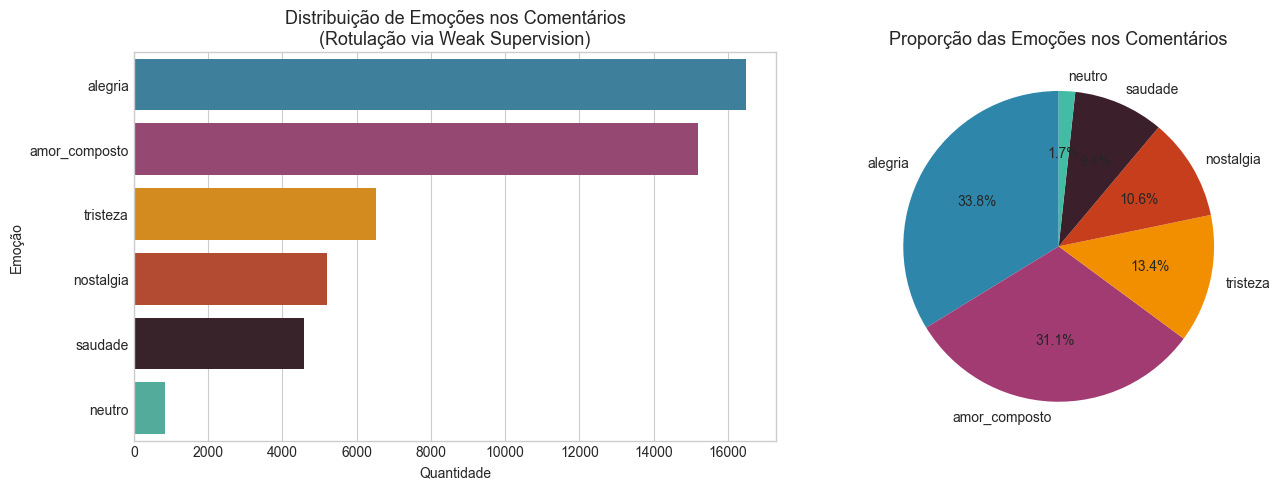

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordem = df_comentarios['emocao'].value_counts().index
sns.countplot(data=df_comentarios, y='emocao', order=ordem, palette=PALETTE, ax=axes[0])
axes[0].set_title('Distribuição de Emoções nos Comentários\n(Rotulação via Weak Supervision)', fontsize=13)
axes[0].set_xlabel('Quantidade')
axes[0].set_ylabel('Emoção')

proporcoes = df_comentarios['emocao'].value_counts(normalize=True) * 100
axes[1].pie(proporcoes, labels=proporcoes.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=90)

axes[1].set_title('Proporção das Emoções nos Comentários', fontsize=13)

plt.tight_layout()
plt.savefig('fig1b_distribuicao_comentarios.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Classe WeightedTrainer e Função preparar_treino

In [14]:
from sklearn.model_selection import train_test_split

class WeightedTrainer(Trainer):
    def __init__(self, *args, pesos_classe=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pesos_classe = pesos_classe

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = nn.CrossEntropyLoss(
            weight=self.pesos_classe.to(logits.device)
        )

        loss = loss_fn(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss


def preparar_treino(
    df,
    coluna_texto,
    coluna_emocao,
    tokenizer,
    max_len=128,
    test_size=0.20,
    val_size=0.10
):

    df = df.copy()

    df["label"] = df[coluna_emocao].map(MAPA_LABELS)

    df_valido = df.dropna(subset=["label"]).copy()

    df_valido["label"] = df_valido["label"].astype(int)
    

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        df_valido[coluna_texto],
        df_valido["label"],
        test_size=test_size,
        random_state=42,
        stratify=df_valido["label"]
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_size,
        random_state=42,
        stratify=y_train_val
    )

    pesos = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )

    pesos = torch.tensor(pesos, dtype=torch.float)

    def tokenizar(textos):
        return tokenizer(
            list(textos),
            truncation=True,
            padding="max_length",
            max_length=max_len
        )

    train_enc = tokenizar(X_train)
    val_enc = tokenizar(X_val)
    test_enc = tokenizar(X_test)

    train_dataset = Dataset.from_dict({
        "input_ids": train_enc["input_ids"],
        "attention_mask": train_enc["attention_mask"],
        "labels": list(y_train)
    })

    val_dataset = Dataset.from_dict({
        "input_ids": val_enc["input_ids"],
        "attention_mask": val_enc["attention_mask"],
        "labels": list(y_val)
    })

    test_dataset = Dataset.from_dict({
        "input_ids": test_enc["input_ids"],
        "attention_mask": test_enc["attention_mask"],
        "labels": list(y_test)
    })

    print(f"Treino: {len(train_dataset)}")
    print(f"Validação: {len(val_dataset)}")
    print(f"Teste: {len(test_dataset)}")

    return (
        train_dataset,
        val_dataset,
        test_dataset,
        pesos,
        y_test
    )

## 11. Tokenizer

In [15]:
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')
print('Tokenizer carregado: neuralmind/bert-base-portuguese-cased')

INFO:httpx:HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/neuralmind/bert-base-portuguese-cased/94d69c95f98f7d5b2a8700c420230ae10def0baa/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/neuralmind/bert-base-portuguese-cased/94d69c95f98f7d5b2a8700c420230ae10def0baa/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased/tree/main?recu

Tokenizer carregado: neuralmind/bert-base-portuguese-cased


## 12. Modelo A Fine-tuning do BERTimbau em Comentários

In [16]:
train_dataset_com, val_dataset_com, test_dataset_com, pesos_com, y_test_com = preparar_treino(
    df_comentarios,
    coluna_texto="texto_limpo",
    coluna_emocao="emocao",
    tokenizer=tokenizer,
    max_len=128
)

Treino: 35150
Validação: 3906
Teste: 9764


In [17]:
bert_model_comentarios = AutoModelForSequenceClassification.from_pretrained(
    'neuralmind/bert-base-portuguese-cased', num_labels=6
)
bert_model_comentarios = bert_model_comentarios.to("cuda") 

training_args_com = TrainingArguments(
    output_dir='./resultados_bert_comentarios',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    logging_dir='./logs_comentarios',
    logging_steps=10,
    fp16=torch.cuda.is_available()
)
trainer_comentarios = WeightedTrainer(
    model=bert_model_comentarios,
    args=training_args_com,
    train_dataset=train_dataset_com,
    eval_dataset=val_dataset_com,
    pesos_classe=pesos_com,
)
trainer_comentarios.train()

INFO:httpx:HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/neuralmind/bert-base-portuguese-cased/94d69c95f98f7d5b2a8700c420230ae10def0baa/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased/commits/main "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Epoch,Training Loss,Validation Loss
1,0.526326,0.752777
2,0.410832,0.671711


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4394, training_loss=0.6875093475384336, metrics={'train_runtime': 921.4045, 'train_samples_per_second': 76.297, 'train_steps_per_second': 4.769, 'total_flos': 4624342872422400.0, 'train_loss': 0.6875093475384336, 'epoch': 2.0})

## 13. Avaliação do Modelo A (Comentários)

In [18]:
predicoes_com = trainer_comentarios.predict(test_dataset_com)
y_pred_com    = np.argmax(predicoes_com.predictions, axis=1)

print('Relatório de Classificação — BERTimbau Fine-tuned (Comentários)')
print(classification_report(y_test_com, y_pred_com, target_names=NOMES_EMOCOES, digits=4))
print(f'Acurácia global: {accuracy_score(y_test_com, y_pred_com)*100:.2f}%')

kappa_com = cohen_kappa_score(y_test_com, y_pred_com)
print(f'\nKappa de Cohen (Snorkel+Gemini vs BERTimbau fine-tuned): {kappa_com:.3f}')
if kappa_com >= 0.8:
    print('Concordância quase perfeita')
elif kappa_com >= 0.6:
    print('Concordância substancial')
elif kappa_com >= 0.4:
    print('Concordância moderada')
else:
    print('Concordância fraca')

Relatório de Classificação — BERTimbau Fine-tuned (Comentários)
               precision    recall  f1-score   support

       neutro     0.3926    0.5689    0.4645       167
      alegria     0.8563    0.7843    0.8187      3297
     tristeza     0.7850    0.8121    0.7983      1304
    nostalgia     0.7182    0.8094    0.7611      1039
amor_composto     0.8082    0.8138    0.8110      3039
      saudade     0.8091    0.8126    0.8109       918

     accuracy                         0.7989      9764
    macro avg     0.7282    0.7669    0.7441      9764
 weighted avg     0.8047    0.7989    0.8007      9764

Acurácia global: 79.89%

Kappa de Cohen (Snorkel+Gemini vs BERTimbau fine-tuned): 0.734
Concordância substancial


## 14. Aplicação do Modelo A no Corpus Completo de Comentários

In [19]:
from tqdm.auto import tqdm
tqdm.pandas(desc="Classificando comentários")

def prever_emocao_comentario(texto):
    inputs = tokenizer(texto, return_tensors='pt', truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(bert_model_comentarios.device) for k, v in inputs.items()}
    bert_model_comentarios.eval()
    with torch.no_grad():
        outputs = bert_model_comentarios(**inputs)
    return NOMES_EMOCOES[torch.argmax(outputs.logits, dim=1).item()]

print('Aplicando Modelo A em todos os comentários...')
df_comentarios['emocao_modelo'] = df_comentarios['texto_limpo'].progress_apply(prever_emocao_comentario)

print('\nDistribuição final da emoção do OUVINTE (Modelo A):')
print(df_comentarios['emocao_modelo'].value_counts())

Aplicando Modelo A em todos os comentários...


Classificando comentários:   0%|          | 0/48820 [00:00<?, ?it/s]


Distribuição final da emoção do OUVINTE (Modelo A):
emocao_modelo
alegria          15251
amor_composto    15216
tristeza          6862
nostalgia         5703
saudade           4639
neutro            1149
Name: count, dtype: int64


## 15. Modelo B Fine-tuning do BERTimbau em Letras de Música

In [20]:
train_dataset_let, val_dataset_let, test_dataset_let, pesos_let, y_test_let = preparar_treino(
    df_letras,
    coluna_texto="texto_limpo",
    coluna_emocao="emocao_silver",
    tokenizer=tokenizer,
    max_len=512
)

Treino: 6048
Validação: 672
Teste: 1680


In [21]:
bert_model_letras = AutoModelForSequenceClassification.from_pretrained(
    'neuralmind/bert-base-portuguese-cased', num_labels=6
)
bert_model_letras = bert_model_letras.to("cuda")  

training_args_let = TrainingArguments(
    output_dir='./resultados_bert_letras',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    logging_dir='./logs_letras',
    logging_steps=10,
    fp16=torch.cuda.is_available()
)
trainer_letras = WeightedTrainer(
    model=bert_model_letras,
    args=training_args_let,
    train_dataset=train_dataset_let,
    eval_dataset=val_dataset_let,
    pesos_classe=pesos_let,
)
trainer_letras.train()

INFO:httpx:HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/neuralmind/bert-base-portuguese-cased/94d69c95f98f7d5b2a8700c420230ae10def0baa/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased/commits/main "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Epoch,Training Loss,Validation Loss
1,1.007518,0.779200
2,0.528790,0.635860
3,0.354890,0.652420
4,0.138982,0.680702


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3024, training_loss=0.6503594911721333, metrics={'train_runtime': 9691.7297, 'train_samples_per_second': 2.496, 'train_steps_per_second': 0.312, 'total_flos': 6365411252895744.0, 'train_loss': 0.6503594911721333, 'epoch': 4.0})

## 16. Avaliação do Modelo B (Letras)

In [22]:
predicoes_let = trainer_letras.predict(test_dataset_let)
y_pred_let    = np.argmax(predicoes_let.predictions, axis=1)

print('Relatório de Classificação — BERTimbau Fine-tuned (Letras)')
print(classification_report(y_test_let, y_pred_let, target_names=NOMES_EMOCOES, digits=4))
print(f'Acurácia global: {accuracy_score(y_test_let, y_pred_let)*100:.2f}%')

kappa_let = cohen_kappa_score(y_test_let, y_pred_let)
print(f'\nKappa de Cohen (Léxico vs BERTimbau fine-tuned): {kappa_let:.3f}')
if kappa_let >= 0.8:
    print('Concordância quase perfeita')
elif kappa_let >= 0.6:
    print('Concordância substancial')
elif kappa_let >= 0.4:
    print('Concordância moderada')
else:
    print('Concordância fraca')

Relatório de Classificação — BERTimbau Fine-tuned (Letras)
               precision    recall  f1-score   support

       neutro     0.7702    0.9095    0.8341       210
      alegria     0.8372    0.6353    0.7224       340
     tristeza     0.7355    0.8690    0.7967       336
    nostalgia     0.7455    0.5395    0.6260        76
amor_composto     0.9000    0.8502    0.8744       614
      saudade     0.6338    0.8654    0.7317       104

     accuracy                         0.8048      1680
    macro avg     0.7704    0.7781    0.7642      1680
 weighted avg     0.8147    0.8048    0.8030      1680

Acurácia global: 80.48%

Kappa de Cohen (Léxico vs BERTimbau fine-tuned): 0.747
Concordância substancial


## 17. Inferência Emocional nas Letras (Modelo B - Janela Deslizante)

In [39]:
def prever_emocao_letra(texto, janela=512, stride=256):
    palavras  = texto.split()
    segmentos = ([texto] if len(palavras) <= janela
                 else [' '.join(palavras[i:i+janela])
                       for i in range(0, len(palavras) - janela + 1, stride)])
    votos = []
    bert_model_letras.eval()
    for seg in segmentos:
        inputs = tokenizer(seg, return_tensors='pt', truncation=True,
                           padding=True, max_length=512)
        inputs = {k: v.to(bert_model_letras.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = bert_model_letras(**inputs)
        votos.append(NOMES_EMOCOES[torch.argmax(outputs.logits, dim=1).item()])
    return Counter(votos).most_common(1)[0][0]

df_letras['emocao_prevista'] = df_letras['texto_limpo'].apply(prever_emocao_letra)
print(f'Inferência concluída — {len(df_letras)} letras processadas.')
print(df_letras['emocao_prevista'].value_counts())

Inferência concluída — 8400 letras processadas.
emocao_prevista
amor_composto    2940
tristeza         1813
alegria          1410
neutro           1257
saudade           666
nostalgia         314
Name: count, dtype: int64


## 18. Distribuição Emocional por Década

decada
1950s       6
1960s     238
1970s     658
1980s     873
1990s    1885
2000s    2592
2010s    1477
2020s     671
Name: count, dtype: int64


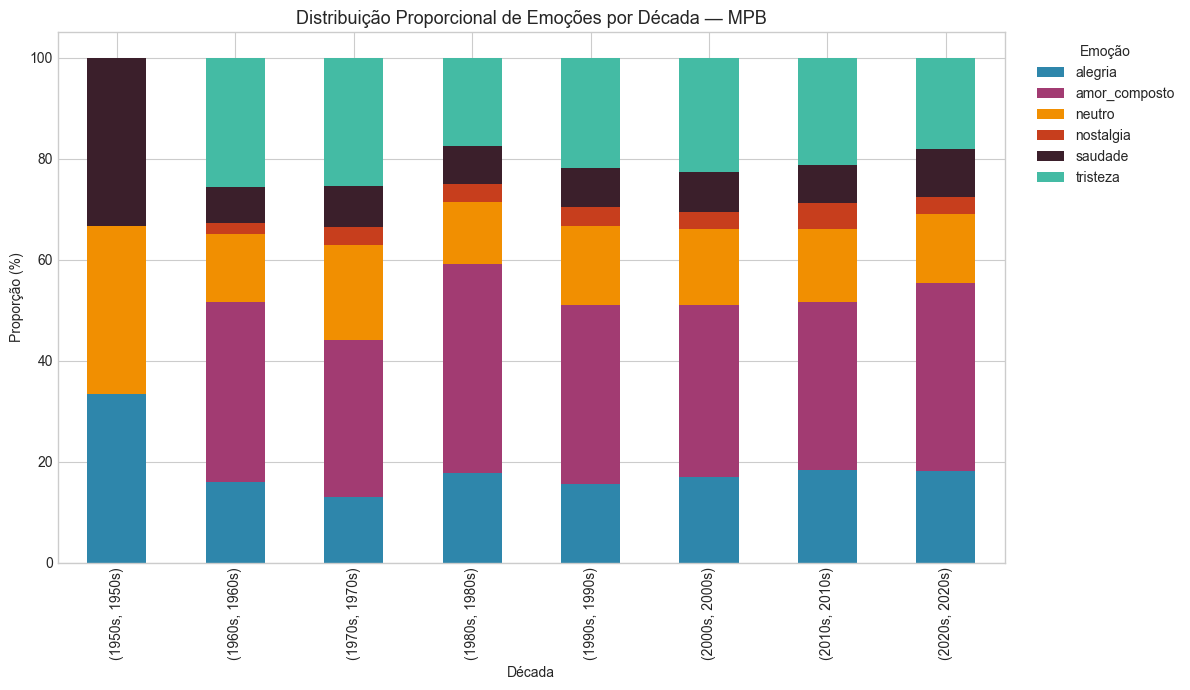


Emoção dominante por década:
decada  decada
1950s   1950s           alegria
1960s   1960s     amor_composto
1970s   1970s     amor_composto
1980s   1980s     amor_composto
1990s   1990s     amor_composto
2000s   2000s     amor_composto
2010s   2010s     amor_composto
2020s   2020s     amor_composto
dtype: object


In [40]:
contagem_decada = df_letras['decada'].value_counts()
print(contagem_decada.sort_index())

proporcao_decada = (
    df_letras.groupby(['decada', 'emocao_prevista']).size()
    .groupby(level=0).apply(lambda x: x / x.sum() * 100)
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 7))
proporcao_decada.plot(kind='bar', stacked=True, color=PALETTE, ax=ax)
ax.set_title('Distribuição Proporcional de Emoções por Década — MPB', fontsize=13)
ax.set_xlabel('Década')
ax.set_ylabel('Proporção (%)')
ax.legend(title='Emoção', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig3_emocoes_por_decada.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEmoção dominante por década:')
print(proporcao_decada.idxmax(axis=1))

In [52]:
print("Quantidade por emoção:")
print(df_letras["emocao_prevista"].value_counts())

print("\nPercentual por emoção:")
print(
    (df_letras["emocao_prevista"]
     .value_counts(normalize=True)
     .mul(100)
     .round(1))
)

Quantidade por emoção:
emocao_prevista
amor_composto    2940
tristeza         1813
alegria          1410
neutro           1257
saudade           666
nostalgia         314
Name: count, dtype: int64

Percentual por emoção:
emocao_prevista
amor_composto    35.0
tristeza         21.6
alegria          16.8
neutro           15.0
saudade           7.9
nostalgia         3.7
Name: proportion, dtype: float64


## 19. Perfil Emocional por Artista

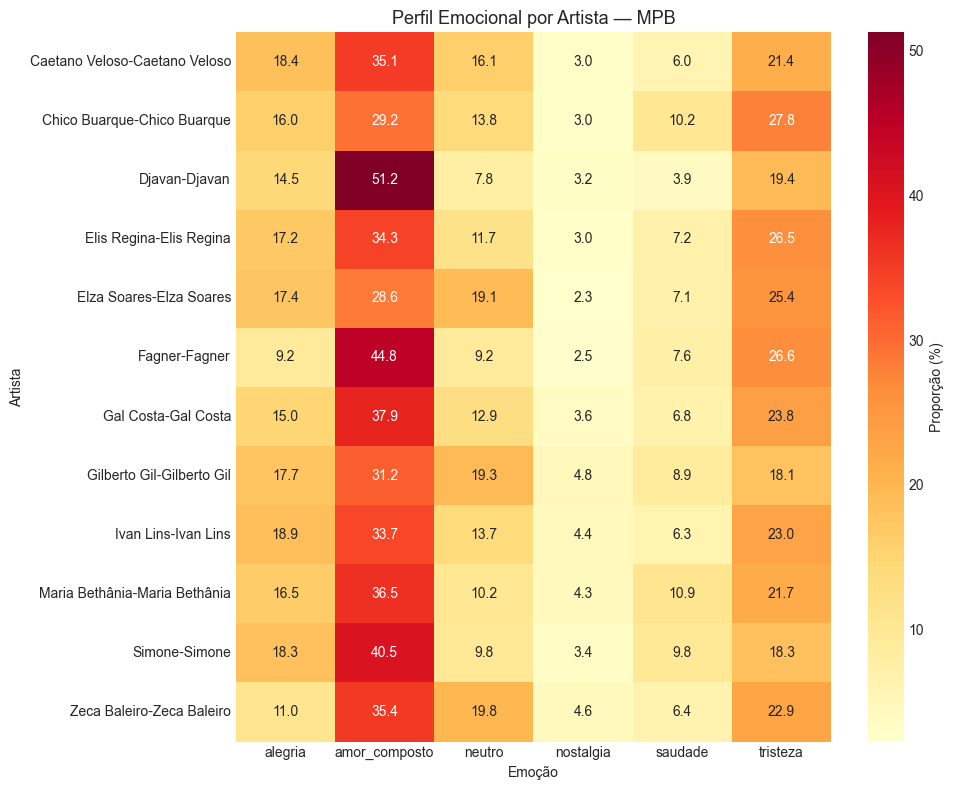

In [41]:
top_artistas  = df_letras['artista'].value_counts().head(12).index
perfil_artista = (
    df_letras[df_letras['artista'].isin(top_artistas)]
    .groupby(['artista', 'emocao_prevista']).size()
    .groupby(level=0).apply(lambda x: x / x.sum() * 100)
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(perfil_artista, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Proporção (%)'})
ax.set_title('Perfil Emocional por Artista — MPB', fontsize=13)
ax.set_xlabel('Emoção')
ax.set_ylabel('Artista')
plt.tight_layout()
plt.savefig('fig4_perfil_emocional_artistas.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Análise Comparativa: Compositor vs. Ouvinte

In [42]:
emocao_por_musica = (
    df_comentarios.groupby(['titulo', 'artista'])['emocao_modelo']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'emocao_modelo': 'emocao_ouvinte'})
)

df_cruzado = (
    pd.merge(
        df_letras[['titulo', 'artista', 'emocao_prevista', 'decada']],
        emocao_por_musica, on=['titulo', 'artista'], how='inner'
    ).rename(columns={'emocao_prevista': 'emocao_compositor'})
)

print(f'Músicas com dados cruzados: {len(df_cruzado)}')
print(f'\nDistribuição compositor (Modelo B):')
print(df_cruzado['emocao_compositor'].value_counts())
print(f'\nDistribuição ouvinte (Modelo A):')
print(df_cruzado['emocao_ouvinte'].value_counts())

Músicas com dados cruzados: 4479

Distribuição compositor (Modelo B):
emocao_compositor
amor_composto    1594
tristeza          954
alegria           756
neutro            632
saudade           361
nostalgia         182
Name: count, dtype: int64

Distribuição ouvinte (Modelo A):
emocao_ouvinte
amor_composto    1609
alegria          1607
nostalgia         450
tristeza          445
saudade           300
neutro             68
Name: count, dtype: int64


In [43]:
df_cruzado['convergencia'] = (
    df_cruzado['emocao_compositor'] == df_cruzado['emocao_ouvinte']
)
taxa_global  = df_cruzado['convergencia'].mean() * 100
kappa_conv   = cohen_kappa_score(df_cruzado['emocao_compositor'],
                                  df_cruzado['emocao_ouvinte'])

print(f'Taxa de convergência global: {taxa_global:.1f}%')
print(f'Kappa de Cohen: {kappa_conv:.3f}')
print('\nConvergência por emoção do compositor:')
print((df_cruzado.groupby('emocao_compositor')['convergencia'].mean() * 100)
      .sort_values(ascending=False).round(1))

Taxa de convergência global: 26.3%
Kappa de Cohen: 0.053

Convergência por emoção do compositor:
emocao_compositor
amor_composto    41.7
alegria          40.2
nostalgia        14.8
tristeza         13.4
saudade          11.6
neutro            1.9
Name: convergencia, dtype: float64


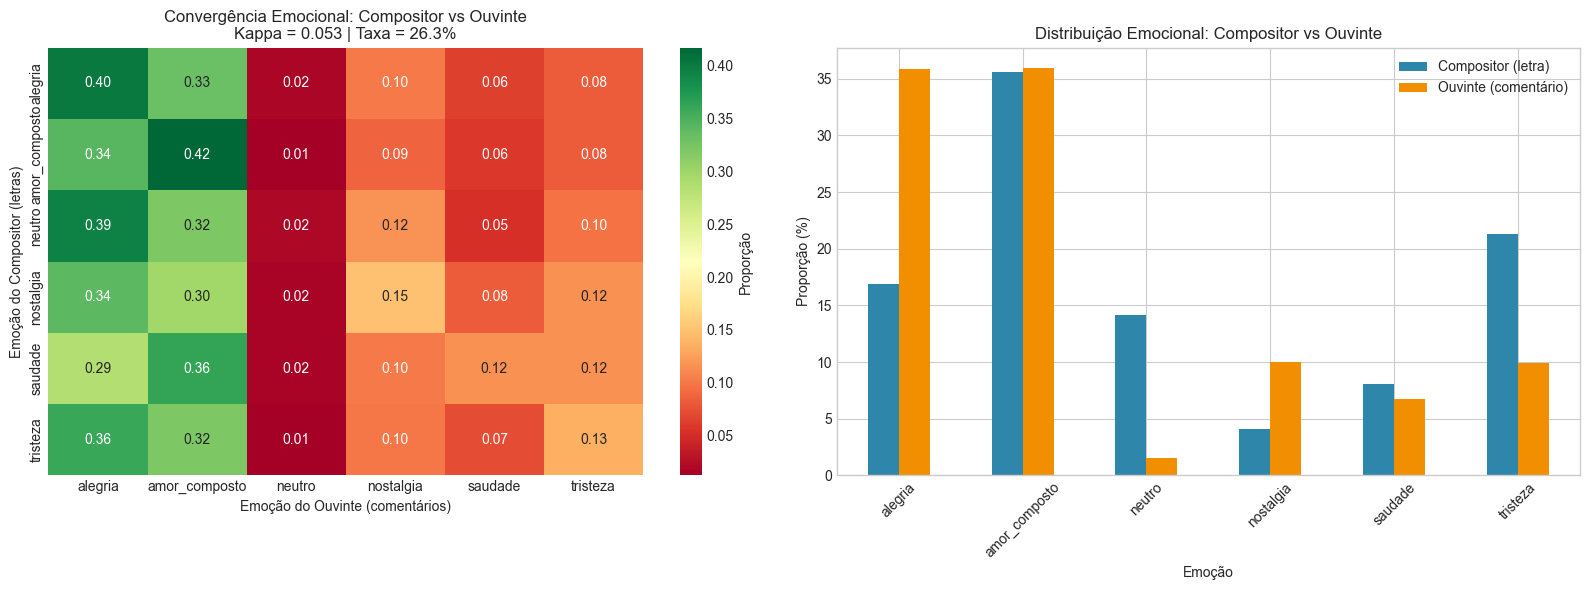

In [44]:
matriz_convergencia = pd.crosstab(
    df_cruzado['emocao_compositor'], df_cruzado['emocao_ouvinte'], normalize='index'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(matriz_convergencia, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0],
            cbar_kws={'label': 'Proporção'})
axes[0].set_title(f'Convergência Emocional: Compositor vs Ouvinte\nKappa = {kappa_conv:.3f} | Taxa = {taxa_global:.1f}%', fontsize=12)
axes[0].set_xlabel('Emoção do Ouvinte (comentários)')
axes[0].set_ylabel('Emoção do Compositor (letras)')

dist_compositor = df_cruzado['emocao_compositor'].value_counts(normalize=True) * 100
dist_ouvinte    = df_cruzado['emocao_ouvinte'].value_counts(normalize=True) * 100
comparacao = pd.DataFrame({'Compositor (letra)': dist_compositor, 'Ouvinte (comentário)': dist_ouvinte}).fillna(0)
comparacao.plot(kind='bar', ax=axes[1], color=['#2E86AB', '#F18F01'])
axes[1].set_title('Distribuição Emocional: Compositor vs Ouvinte', fontsize=12)
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('Emoção')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig5_compositor_vs_ouvinte.png', dpi=150, bbox_inches='tight')
plt.show()

### 20.1 Pares de Divergência Mais Frequentes

In [45]:
divergencias = df_cruzado[~df_cruzado['convergencia']].copy()
print(f'Total de divergências: {len(divergencias)} ({len(divergencias)/len(df_cruzado)*100:.1f}%)')
print('\nPares mais frequentes (compositor → ouvinte):')
print(divergencias.groupby(['emocao_compositor', 'emocao_ouvinte']).size()
      .sort_values(ascending=False).head(10))

print('\nExemplos de músicas com divergência emocional:')
for _, row in divergencias.sample(min(5, len(divergencias)), random_state=42).iterrows():
    print(f'  \"{row["titulo"]}\" ({row["artista"]}) — '
          f'compositor: {row["emocao_compositor"]} | ouvinte: {row["emocao_ouvinte"]}')

Total de divergências: 3302 (73.7%)

Pares mais frequentes (compositor → ouvinte):
emocao_compositor  emocao_ouvinte
amor_composto      alegria           546
tristeza           alegria           343
                   amor_composto     306
alegria            amor_composto     251
neutro             alegria           249
                   amor_composto     203
amor_composto      nostalgia         140
saudade            amor_composto     131
amor_composto      tristeza          131
saudade            alegria           103
dtype: int64

Exemplos de músicas com divergência emocional:
  "Graffitis" (Adriana Calcanhotto) — compositor: amor_composto | ouvinte: nostalgia
  "Luz Dos Olhos" (Cássia Eller) — compositor: alegria | ouvinte: saudade
  "O Homem Que Eu Amo" (Fafá de Belém) — compositor: amor_composto | ouvinte: tristeza
  "Vamos Fugir" (Gilberto Gil) — compositor: neutro | ouvinte: nostalgia
  "Vampira" (Alceu Valença) — compositor: neutro | ouvinte: saudade


## 21. Modelagem de Tópicos com LDA por Emoção

In [46]:
STOPWORDS_PT = set([
    'a','o','as','os','de','da','do','das','dos','em','um','uma','uns','umas',
    'para','com','sem','por','sobre','entre','que','se','na','no','nas','nos',
    'e','ou','mas','como','mais','muito','já','é','foi','ser','ter','tem',
    'minha','meu','seu','sua','teu','tua','eu','tu','ele','ela','nós','você',
    'vocês','eles','elas','isso','isto','aquilo','essa','esse','esta','este',
    'pra','pro','num','numa','ao','aos','à','às'
])

def preparar_tokens_lda(texto):
    tokens = simple_preprocess(texto, deacc=False)
    return [t for t in tokens if t not in STOPWORDS_PT and len(t) > 2]

df_letras['tokens_lda'] = df_letras['texto_limpo'].apply(preparar_tokens_lda)

In [47]:
def treinar_lda(tokens, n_topicos=3, passes=15):
    dicionario = corpora.Dictionary(tokens)
    dicionario.filter_extremes(no_below=2, no_above=0.9)
    corpus  = [dicionario.doc2bow(t) for t in tokens]
    lda     = LdaModel(corpus=corpus, id2word=dicionario, num_topics=n_topicos,
                        random_state=42, passes=passes, alpha='auto')
    coerencia = CoherenceModel(model=lda, texts=tokens, dictionary=dicionario,
                                coherence='c_v').get_coherence()
    return lda, coerencia

resultados_lda = {}
for emocao in NOMES_EMOCOES:
    subset = df_letras[df_letras['emocao_prevista'] == emocao]['tokens_lda'].tolist()
    if len(subset) < 10:
        continue
    lda, coer = treinar_lda(subset)
    resultados_lda[emocao] = {'modelo': lda, 'coerencia': coer, 'n': len(subset)}
    print(f'  [{emocao}] n={len(subset):3d} | Cv = {coer:.3f}')

INFO:gensim.corpora.dictionary:adding document #0 to Dictionary<0 unique tokens: []>
INFO:gensim.corpora.dictionary:built Dictionary<11389 unique tokens: ['bunda', 'estuda', 'faz', 'funk', 'luta']...> from 1257 documents (total 88105 corpus positions)
INFO:gensim.utils:Dictionary lifecycle event {'msg': "built Dictionary<11389 unique tokens: ['bunda', 'estuda', 'faz', 'funk', 'luta']...> from 1257 documents (total 88105 corpus positions)", 'datetime': '2026-08-04T01:47:21.132613', 'gensim': '4.4.0', 'python': '3.10.20 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:13:20) [MSC v.1942 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
INFO:gensim.corpora.dictionary:discarding 6429 tokens: [('estuda', 1), ('magenta', 1), ('delta', 1), ('hélio', 1), ('pamplona', 1), ('parangolé', 1), ('retângulo', 1), ('êxtase', 1), ('assoprou', 1), ('baste', 1)]...
INFO:gensim.corpora.dictionary:keeping 4960 tokens which were in no less than 2 and no more than 1131 (=90.

  [neutro] n=1257 | Cv = 0.327


INFO:gensim.models.ldamodel:using symmetric eta at 0.3333333333333333
INFO:gensim.models.ldamodel:using serial LDA version on this node
INFO:gensim.models.ldamodel:running online (multi-pass) LDA training, 3 topics, 15 passes over the supplied corpus of 1410 documents, updating model once every 1410 documents, evaluating perplexity every 1410 documents, iterating 50x with a convergence threshold of 0.001000
INFO:gensim.models.ldamodel:-9.340 per-word bound, 648.0 perplexity estimate based on a held-out corpus of 1410 documents with 117087 words
INFO:gensim.models.ldamodel:PROGRESS: pass 0, at document #1410/1410
INFO:gensim.models.ldamodel:optimized alpha [np.float32(0.44170392), np.float32(0.47935292), np.float32(0.45757028)]
INFO:gensim.models.ldamodel:topic #0 (0.442): 0.026*"não" + 0.009*"vida" + 0.009*"quando" + 0.008*"vai" + 0.008*"amor" + 0.008*"tão" + 0.007*"quem" + 0.007*"bom" + 0.006*"feliz" + 0.006*"mundo"
INFO:gensim.models.ldamodel:topic #1 (0.479): 0.028*"não" + 0.011*"te

  [alegria] n=1410 | Cv = 0.378


INFO:gensim.models.ldamodel:using autotuned alpha, starting with [np.float32(0.33333334), np.float32(0.33333334), np.float32(0.33333334)]
INFO:gensim.models.ldamodel:using symmetric eta at 0.3333333333333333
INFO:gensim.models.ldamodel:using serial LDA version on this node
INFO:gensim.models.ldamodel:running online (multi-pass) LDA training, 3 topics, 15 passes over the supplied corpus of 1813 documents, updating model once every 1813 documents, evaluating perplexity every 1813 documents, iterating 50x with a convergence threshold of 0.001000
INFO:gensim.models.ldamodel:-9.438 per-word bound, 693.9 perplexity estimate based on a held-out corpus of 1813 documents with 144086 words
INFO:gensim.models.ldamodel:PROGRESS: pass 0, at document #1813/1813
INFO:gensim.models.ldamodel:optimized alpha [np.float32(0.4059775), np.float32(0.49444628), np.float32(0.45485234)]
INFO:gensim.models.ldamodel:topic #0 (0.406): 0.021*"não" + 0.011*"vai" + 0.010*"quem" + 0.010*"vida" + 0.009*"amor" + 0.009*"

...

  [nostalgia] n=314 | Cv = 0.285


INFO:gensim.models.ldamodel:using autotuned alpha, starting with [np.float32(0.33333334), np.float32(0.33333334), np.float32(0.33333334)]
INFO:gensim.models.ldamodel:using symmetric eta at 0.3333333333333333
INFO:gensim.models.ldamodel:using serial LDA version on this node
INFO:gensim.models.ldamodel:running online (multi-pass) LDA training, 3 topics, 15 passes over the supplied corpus of 2940 documents, updating model once every 2000 documents, evaluating perplexity every 2940 documents, iterating 50x with a convergence threshold of 0.001000
INFO:gensim.models.ldamodel:PROGRESS: pass 0, at document #2000/2940
INFO:gensim.models.ldamodel:optimized alpha [np.float32(0.4518057), np.float32(0.505527), np.float32(0.37845612)]
INFO:gensim.models.ldamodel:merging changes from 2000 documents into a model of 2940 documents
INFO:gensim.models.ldamodel:topic #0 (0.452): 0.029*"não" + 0.022*"amor" + 0.012*"quem" + 0.009*"vai" + 0.009*"coração" + 0.008*"vou" + 0.007*"quando" + 0.007*"sei" + 0.006*

  [amor_composto] n=2940 | Cv = 0.403


INFO:gensim.models.ldamodel:-8.827 per-word bound, 454.0 perplexity estimate based on a held-out corpus of 666 documents with 53236 words
INFO:gensim.models.ldamodel:PROGRESS: pass 0, at document #666/666
INFO:gensim.models.ldamodel:optimized alpha [np.float32(0.4625848), np.float32(0.4468186), np.float32(0.47303373)]
INFO:gensim.models.ldamodel:topic #0 (0.463): 0.032*"não" + 0.013*"saudade" + 0.012*"vou" + 0.010*"quando" + 0.010*"amor" + 0.009*"deus" + 0.009*"vai" + 0.007*"dia" + 0.007*"tudo" + 0.006*"tão"
INFO:gensim.models.ldamodel:topic #1 (0.447): 0.025*"não" + 0.011*"amor" + 0.010*"saudade" + 0.009*"quero" + 0.007*"tempo" + 0.007*"mar" + 0.007*"sou" + 0.007*"mundo" + 0.006*"sei" + 0.006*"tudo"
INFO:gensim.models.ldamodel:topic #2 (0.473): 0.040*"não" + 0.010*"gente" + 0.009*"quem" + 0.009*"vou" + 0.009*"saudade" + 0.009*"quero" + 0.008*"vida" + 0.008*"mim" + 0.007*"dia" + 0.007*"mundo"
INFO:gensim.models.ldamodel:topic diff=1.301329, rho=1.000000
INFO:gensim.models.ldamodel:-7.3

  [saudade] n=666 | Cv = 0.344


In [48]:
print('TÓPICOS POR EMOÇÃO - MPB')
print('=' * 55)
for emocao, dados in resultados_lda.items():
    print(f'\nEMOÇÃO: {emocao.upper()} (n={dados["n"]} | Cv={dados["coerencia"]:.3f})')
    print('-' * 45)
    for i, topico in dados['modelo'].print_topics(num_topics=3, num_words=8):
        palavras = [p.split('*')[1].strip().replace('"', '') for p in topico.split(' + ')]
        print(f'  Tópico {i+1}: {", ".join(palavras)}')

INFO:gensim.models.ldamodel:topic #0 (0.082): 0.027*"não" + 0.014*"vai" + 0.010*"vou" + 0.009*"quando" + 0.008*"gente" + 0.008*"bem" + 0.007*"samba" + 0.007*"quero"
INFO:gensim.models.ldamodel:topic #1 (0.122): 0.056*"não" + 0.010*"vai" + 0.009*"vou" + 0.009*"quero" + 0.009*"tudo" + 0.008*"vem" + 0.008*"ver" + 0.008*"quem"
INFO:gensim.models.ldamodel:topic #2 (0.060): 0.027*"não" + 0.012*"sou" + 0.011*"quem" + 0.008*"mundo" + 0.008*"cai" + 0.007*"tudo" + 0.006*"todo" + 0.006*"dia"
INFO:gensim.models.ldamodel:topic #0 (0.082): 0.026*"não" + 0.010*"vida" + 0.009*"vai" + 0.009*"quando" + 0.008*"tão" + 0.008*"bom" + 0.008*"quem" + 0.007*"amor"
INFO:gensim.models.ldamodel:topic #1 (0.075): 0.021*"não" + 0.013*"tempo" + 0.010*"amor" + 0.007*"gente" + 0.007*"beleza" + 0.006*"quem" + 0.006*"bem" + 0.006*"quando"
INFO:gensim.models.ldamodel:topic #2 (0.097): 0.043*"não" + 0.013*"amor" + 0.011*"vou" + 0.010*"quero" + 0.010*"vem" + 0.009*"vai" + 0.009*"bem" + 0.008*"tudo"
INFO:gensim.models.ldamo

TÓPICOS POR EMOÇÃO - MPB

EMOÇÃO: NEUTRO (n=1257 | Cv=0.327)
---------------------------------------------
  Tópico 1: não, vai, vou, quando, gente, bem, samba, quero
  Tópico 2: não, vai, vou, quero, tudo, vem, ver, quem
  Tópico 3: não, sou, quem, mundo, cai, tudo, todo, dia

EMOÇÃO: ALEGRIA (n=1410 | Cv=0.378)
---------------------------------------------
  Tópico 1: não, vida, vai, quando, tão, bom, quem, amor
  Tópico 2: não, tempo, amor, gente, beleza, quem, bem, quando
  Tópico 3: não, amor, vou, quero, vem, vai, bem, tudo

EMOÇÃO: TRISTEZA (n=1813 | Cv=0.385)
---------------------------------------------
  Tópico 1: não, quem, vem, vai, dia, mar, sol, vida
  Tópico 2: não, tudo, amor, quero, vida, vai, quem, mim
  Tópico 3: não, vou, vai, sou, quando, nem, sei, quem

EMOÇÃO: NOSTALGIA (n=314 | Cv=0.285)
---------------------------------------------
  Tópico 1: não, quem, tempo, sou, vida, tudo, bem, sei
  Tópico 2: não, quando, anos, está, quero, coisas, vinte, assim
  Tópico 3

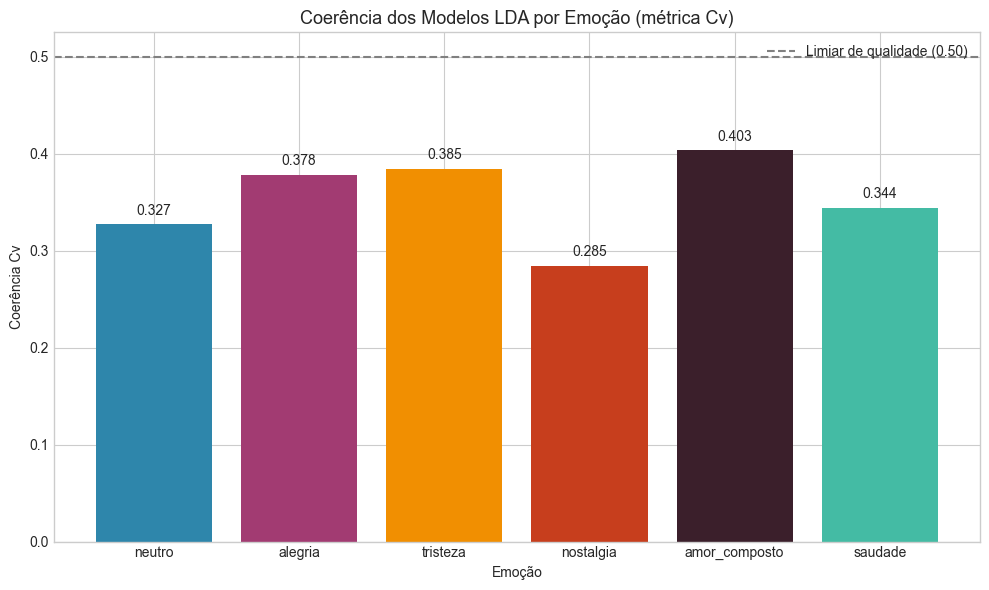

In [49]:
coerencias = {e: d['coerencia'] for e, d in resultados_lda.items()}
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(coerencias.keys(), coerencias.values(), color=PALETTE[:len(coerencias)])
ax.axhline(0.5, color='gray', linestyle='--', label='Limiar de qualidade (0.50)')
ax.set_title('Coerência dos Modelos LDA por Emoção (métrica Cv)', fontsize=13)
ax.set_ylabel('Coerência Cv')
ax.set_xlabel('Emoção')
for i, (k, v) in enumerate(coerencias.items()):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_coerencia_lda.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Resumo dos Resultados

In [50]:
print('=' * 55)
print('RESUMO DOS RESULTADOS')
print('=' * 55)
print(f'  Letras analisadas:               {len(df_letras)}')
print(f'  Comentários analisados:          {len(df_comentarios)}')
print(f'  Acurácia BERTimbau (comentários): {accuracy_score(y_test_com, y_pred_com)*100:.1f}%')
print(f'  Acurácia BERTimbau (letras):      {accuracy_score(y_test_let, y_pred_let)*100:.1f}%')
print(f'  Kappa validação (comentários):    {kappa_com:.3f}')
print(f'  Kappa validação (letras):         {kappa_let:.3f}')
print(f'  Convergência comp./ouvinte:       {taxa_global:.1f}%')
print(f'  Kappa convergência:               {kappa_conv:.3f}')
print(f'  Músicas cruzadas:                 {len(df_cruzado)}')

RESUMO DOS RESULTADOS
  Letras analisadas:               8400
  Comentários analisados:          48820
  Acurácia BERTimbau (comentários): 79.9%
  Acurácia BERTimbau (letras):      80.5%
  Kappa validação (comentários):    0.734
  Kappa validação (letras):         0.747
  Convergência comp./ouvinte:       26.3%
  Kappa convergência:               0.053
  Músicas cruzadas:                 4479


## 23. Exportação dos Resultados

In [51]:
df_letras[['titulo', 'artista', 'ano', 'decada', 'emocao_prevista']].to_csv(
    'letras_com_emocoes_v2.csv', index=False, encoding='utf-8-sig'
)
df_comentarios[['titulo', 'artista', 'comentario', 'emocao_modelo']].to_csv(
    'comentarios_com_emocoes_v2.csv', index=False, encoding='utf-8-sig'
)
df_cruzado.to_csv('cruzamento_compositor_ouvinte_v2.csv', index=False, encoding='utf-8-sig')

print('Arquivos gerados:')
print('  letras_com_emocoes_v2.csv')
print('  comentarios_com_emocoes_v2.csv')
print('  cruzamento_compositor_ouvinte_v2.csv')
print('  fig1a_distribuicao_letras.png')
print('  fig1b_distribuicao_comentarios.png')
print('  fig3_emocoes_por_decada.png')
print('  fig4_perfil_emocional_artistas.png')
print('  fig5_compositor_vs_ouvinte.png')
print('  fig6_coerencia_lda.png')

Arquivos gerados:
  letras_com_emocoes_v2.csv
  comentarios_com_emocoes_v2.csv
  cruzamento_compositor_ouvinte_v2.csv
  fig1a_distribuicao_letras.png
  fig1b_distribuicao_comentarios.png
  fig3_emocoes_por_decada.png
  fig4_perfil_emocional_artistas.png
  fig5_compositor_vs_ouvinte.png
  fig6_coerencia_lda.png
